In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

# 1. 核心魔法：軟閾值函數 (Soft Thresholding)
# 這是 Lasso 能產生 "0" 的數學原因
def soft_threshold(rho, lam):
    """
    rho: 如果不加處罰項，這個特徵應該要有的係數強度 (相關性)
    lam: 懲罰力度 (Lambda/Alpha)
    """
    if rho > lam:
        return rho - lam
    elif rho < -lam:
        return rho + lam
    else:
        return 0.0  # <--- 這裡就是將係數歸零的關鍵！

# 2. 手刻 Coordinate Descent Lasso
def lasso_coordinate_descent(X, y, alpha, epochs=1000):
    n_samples, n_features = X.shape

    # 初始化權重 (全部設為 0)
    w = np.zeros(n_features)

    # 為了對齊 sklearn 的公式定義，這裡做一些調整
    # sklearn 的目標函數包含 (1 / (2 * n_samples))，所以 lambda 要乘上 n_samples
    lam = alpha * n_samples

    # 預先計算每個特徵的平方和 (分母)
    # z = Sigma^N_{i=1}(X_i^2)
    z = np.sum(X**2, axis=0)

    loss_hist = []

    # 開始疊代
    for epoch in range(epochs):

        for j in range(n_features):
            # --- 步驟 A: 準備 ---
            # 先把目前的權重 w[j] 拿掉，計算 "沒有 feature j 參與時的預測值"
            # 為了加速，我們先算目前的誤差，再把 w[j] 的貢獻加回去
            # residual_i = y_i-(Sigma_{k!=j} X_ik*w_k)
            y_pred = X @ w
            residual = y - y_pred + X[:, j]*w[j]

            # --- 步驟 B: 計算 rho (相關性) ---
            # rho 代表：如果沒有懲罰，feature j 應該要負擔多少誤差
            # 公式：x_j dot (residual + w_j * x_j)
            # Sigma^N_{i=1}(residual*X_i)
            # 程式兩個都是1維array，所以np會當作2個向量做點積
            rho = X[:, j] @ (residual)

            # --- 步驟 C: 更新 w[j] (使用軟閾值) ---
            # 公式：w_j = S(rho, lambda) / z_j
            w[j] = soft_threshold(rho, lam) / z[j]

        # Loss
        y_pred = X @ w
        loss = 0.5*np.mean((y - y_pred)**2) + alpha*np.sum(np.abs(w))
        loss_hist.append(loss)

    return w, loss_hist

In [56]:
# ==========================================
# 測試環節
# ==========================================

# 1. 產生數據
np.random.seed(42)
n_samples, n_features = 50, 10
X = np.random.randn(n_samples, n_features)

# 真實權重：只有前 3 個特徵有用，後面 7 個都是雜訊 (應該要是 0)
true_coef = np.array([5, -3, 2, 0, 0, 8, 0, 0, 0, 0])
# 產生 y (加上一點噪音)
y = X @ true_coef + 0.5 * np.random.randn(n_samples)

# 設定 alpha (懲罰力度)
alpha = 0.1

# 2. 跑我們手寫的 Lasso
my_w, loss_hist = lasso_coordinate_descent(X, y, alpha=alpha, epochs=20)

# 3. 跑 Sklearn 的 Lasso (當作標準答案)
sklearn_model = Lasso(alpha=alpha, fit_intercept=False) # 為了簡化，不看截距
sklearn_model.fit(X, y)
sklearn_w = sklearn_model.coef_

# 4. 結果比較
print(f"{'Feature':<10} | {'True Coef':<10} | {'My Lasso':<10} | {'Sklearn':<10}")
print("-" * 50)
for i in range(n_features):
    print(f"feat_{i:<5} | {true_coef[i]:<10.2f} | {my_w[i]:<10.4f} | {sklearn_w[i]:<10.4f}")

print("-" * 50)

Feature    | True Coef  | My Lasso   | Sklearn   
--------------------------------------------------
feat_0     | 5.00       | 4.8561     | 4.8560    
feat_1     | -3.00      | -2.9782    | -2.9785   
feat_2     | 2.00       | 1.9952     | 1.9953    
feat_3     | 0.00       | -0.0025    | -0.0024   
feat_4     | 0.00       | 0.0000     | 0.0000    
feat_5     | 8.00       | 7.8932     | 7.8930    
feat_6     | 0.00       | 0.0000     | -0.0000   
feat_7     | 0.00       | 0.0000     | 0.0000    
feat_8     | 0.00       | -0.0096    | -0.0097   
feat_9     | 0.00       | -0.0004    | -0.0005   
--------------------------------------------------


In [67]:
X = np.random.randn(n_samples, n_features)
y_my = X @ my_w
y_gt = X @ true_coef
y_sk = sklearn_model.predict(X)
# print(f"y_my: {y_my}")
# print(f"y_gt: {y_gt}")
# print(f"y_sk: {y_sk}")
y_sk.shape

(50,)

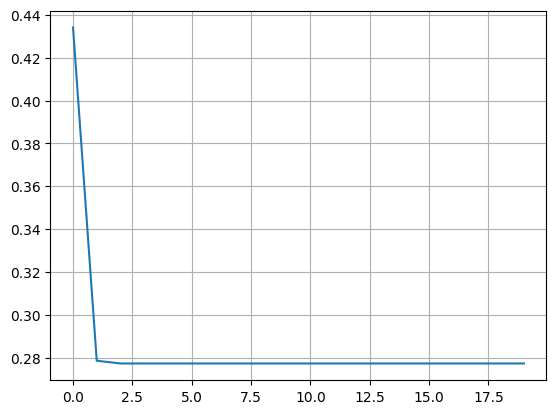

In [57]:
fig = plt.Figure()
loss_hist_log = np.log10(loss_hist)
plt.plot(loss_hist_log)
plt.grid()